The project motive is I want to create a website, when user upload a image then it will all the color code of every pixel which is help developer to find best color as per their choice.

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from PIL import Image
from sklearn.cluster import KMeans

In [2]:

from PIL import Image
import numpy as np
from sklearn.cluster import KMeans

class KMeansPixelModel:

    def __init__(self, k=5):
        self.k = k
        self.model = KMeans(n_clusters=k, random_state=42)
        self.image_array = None
        self.labels = None
        self.width = None
        self.height = None

    def load_and_train(self, image_path):
        # Load image
        image = Image.open(image_path).convert("RGB")
        self.image_array = np.array(image)

        self.height, self.width, _ = self.image_array.shape

        # Flatten image → (num_pixels, 3)
        pixels = self.image_array.reshape(-1, 3)
        print(pixels)

        # Train K-Means
        self.labels = self.model.fit_predict(pixels)

        return {
            "message": "Model trained",
            "clusters": self.k
        }

    def get_pixel_info(self, x, y):
        if self.image_array is None:
            raise Exception("Model not trained")

        if x < 0 or y < 0 or x >= self.width or y >= self.height:
            return {"error": "Out of bounds"}

        # Exact RGB
        r, g, b = self.image_array[y, x]

        # Get cluster label
        index = y * self.width + x
        cluster_id = int(self.labels[index])

        return {
            "r": int(r),
            "g": int(g),
            "b": int(b),
            "hex": self.rgb_to_hex(r, g, b),
            "cluster": cluster_id
        }

    def rgb_to_hex(self, r, g, b):
        return '#{:02x}{:02x}{:02x}'.format(r, g, b)

In [3]:
if __name__ == "__main__":
    model = KMeansPixelModel(k=5)

    model.load_and_train(r"C:\Users\HP\OneDrive\Pictures\Saved Pictures\mohit_img.jpg")

    x, y = 100, 150
    result = model.get_pixel_info(x, y)

    print(result)

[[  3 169 245]
 [  3 169 245]
 [  3 169 245]
 ...
 [ 37  60 102]
 [ 34  57  99]
 [ 34  57  99]]
{'r': 54, 'g': 91, 'b': 171, 'hex': '#365bab', 'cluster': 2}


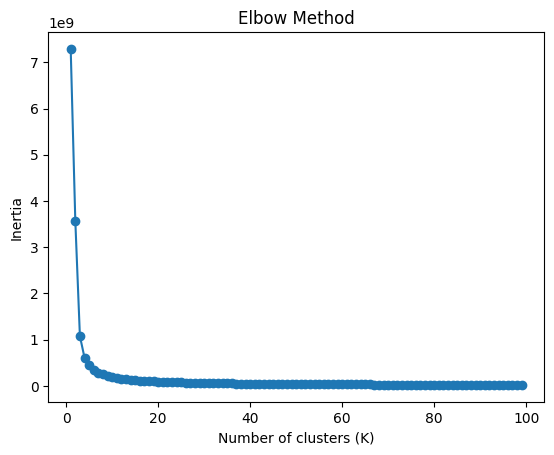

In [5]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def find_optimal_k(pixels):
    inertia = []
    k_range = range(1, 100)

    for k in k_range:
        model = KMeans(n_clusters=k, random_state=42)
        model.fit(pixels)
        inertia.append(model.inertia_)

    plt.figure()
    plt.plot(k_range, inertia, marker='o')
    plt.xlabel("Number of clusters (K)")
    plt.ylabel("Inertia")
    plt.title("Elbow Method")
    plt.show()
    
pixels_sample = pixels[np.random.choice(len(pixels), 10000, replace=False)]
find_optimal_k(pixels)